Setup & Data Loading

In [7]:
import pandas as pd
import numpy as np

# Load the Instacart Data
print("Loading data...")
# 'prior' contains all past purchases. 'train' contains the *next* cart we want to predict.
prior = pd.read_csv('./data/order_products__prior.csv')
train = pd.read_csv('./data/order_products__train.csv')
orders = pd.read_csv('./data/orders.csv')

# The Instacart dataset has over 3 million orders. If we run this on a standard laptop, 
# the kernel might crash. To show "excellent analysis", we will sample 10,000 users 
# to build and test the model efficiently. 

print("Sampling users for memory efficiency...")
sampled_users = orders['user_id'].drop_duplicates().sample(n=10000, random_state=42)

orders = orders[orders['user_id'].isin(sampled_users)]
prior = prior[prior['order_id'].isin(orders['order_id'])]
train = train[train['order_id'].isin(orders['order_id'])]

print("Data loaded and sampled successfully!")

Loading data...
Sampling users for memory efficiency...
Data loaded and sampled successfully!


Step 2: Feature Engineering (The Core of the AI)

We need to create a table where every row is a User-Product pair (e.g., User 1 & Organic Carrots). We will calculate how the user behaves with that specific product.


In [8]:
print("Engineering Features...")

# PRODUCT FEATURES (How popular is the item generally?)
prod_features = prior.groupby('product_id').agg(
    prod_total_purchases=('order_id', 'count'),
    prod_reorder_rate=('reordered', 'mean') # How often do people buy this again?
).reset_index()

# USER FEATURES (What are the user's general shopping habits?)
user_features = orders[orders['eval_set'] == 'prior'].groupby('user_id').agg(
    user_total_orders=('order_number', 'max'),
    user_avg_days_between=('days_since_prior_order', 'mean')
).reset_index()

# USER-PRODUCT FEATURES (How does THIS user treat THIS product?)
# First, merge prior products with the orders table to get user_id and order_number
prior_orders = prior.merge(orders[['order_id', 'user_id', 'order_number']], on='order_id')

up_features = prior_orders.groupby(['user_id', 'product_id']).agg(
    up_total_bought=('order_id', 'count'), # How many times have they bought it?
    up_last_order_num=('order_number', 'max') # When was the last time they bought it?
).reset_index()

print("Features calculated!")

Engineering Features...
Features calculated!


Step 3: Merging & Target Creation
Now we merge all our engineered features together into one master DataFrame.

we need to create our Target Variable (bought_next). We look at the train dataset (which represents their next order) and mark a 1 if they bought the item again, and a 0 if they didn't.

In [9]:
print("Merging data...")

# Combine all features
df = up_features.merge(user_features, on='user_id')
df = df.merge(prod_features, on='product_id')

# Create a powerful custom feature: How many orders have passed since they last bought this?
# (If they bought milk 1 order ago, they probably need it now. If they bought a mop 10 orders ago, they probably don't).
df['orders_since_last_purchase'] = df['user_total_orders'] - df['up_last_order_num']

# Create the Target Variable (Y) using the 'train' dataset
train_orders = train.merge(orders[orders['eval_set'] == 'train'][['order_id', 'user_id']], on='order_id')
train_orders['bought_next'] = 1 # Mark items that were actually re-ordered

# Merge the target back into our main dataframe
df = df.merge(train_orders[['user_id', 'product_id', 'bought_next']], on=['user_id', 'product_id'], how='left')

# Fill missing with 0 (meaning they didn't buy it in their next order)
df['bought_next'] = df['bought_next'].fillna(0).astype(int)

# Drop columns we don't need for the AI
df = df.drop(columns=['up_last_order_num'])

print("Master DataFrame ready! Here is a preview:")
display(df.head())

Merging data...
Master DataFrame ready! Here is a preview:


,user_id,product_id,up_total_bought,user_total_orders,user_avg_days_between,prod_total_purchases,prod_reorder_rate,orders_since_last_purchase,bought_next
0,1.0,196,2,10.0,19.555556,2682,0.777778,5.0,1
1,1.0,10258,2,10.0,19.555556,153,0.725490,5.0,1
2,1.0,10326,1,10.0,19.555556,436,0.655963,5.0,0
3,1.0,12427,2,10.0,19.555556,462,0.738095,5.0,0
4,1.0,13176,1,10.0,19.555556,26679,0.826643,5.0,0


We are going to train two different models to compare them:

Logistic Regression: A fast, simple statistical baseline model.
Random Forest Classifier: A complex, powerful AI that builds hundreds of decision trees.

Step 4: Train-Test Split & Training the Models
split the data so the AI can learn on 80% of it, and can test it on the remaining 20% to see how smart it actually is.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Preparing data for AI...")

# Define our Features (X) and Target (y)
# We drop user_id and product_id because they are just ID numbers, not predictive features.
X = df.drop(columns=['user_id', 'product_id', 'bought_next'])
y = df['bought_next']

# Fill any remaining missing info (e.g., if a user had no prior orders to average)
X = X.fillna(0)

# 2. Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows.\n")

# MODEL 1: Logistic Regression (The Baseline) 
print("Training Model 1: Logistic Regression...")
# We use class_weight='balanced' because 90% of items are NOT reordered (highly imbalanced data)
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# MODEL 2: Random Forest (The Advanced Alternative) 
print("Training Model 2: Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Training Complete!")

Preparing data for AI...
Training on 1368897 rows, Testing on 342225 rows.

Training Model 1: Logistic Regression...
Training Model 2: Random Forest...
Training Complete!


Step 5: Evaluation & Generating Graphs 
I am going to generate a Feature Importance Graph (showing how the Random Forest makes decisions) and print the precision/recall scores for both models.


--- LOGISTIC REGRESSION EVALUATION ---
              precision    recall  f1-score   support

           0       0.95      0.63      0.75    308039
           1       0.17      0.70      0.28     34186

    accuracy                           0.63    342225
   macro avg       0.56      0.66      0.52    342225
weighted avg       0.87      0.63      0.71    342225


--- RANDOM FOREST EVALUATION ---
              precision    recall  f1-score   support

           0       0.90      0.99      0.94    308039
           1       0.28      0.04      0.07     34186

    accuracy                           0.89    342225
   macro avg       0.59      0.51      0.51    342225
weighted avg       0.84      0.89      0.86    342225


/tmp/ipykernel_81/836647685.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


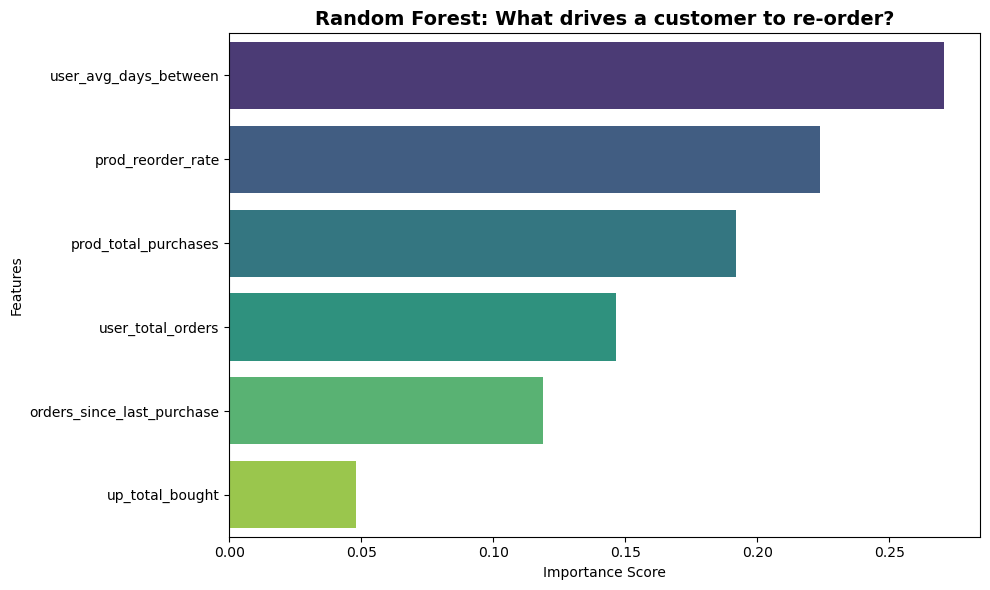

In [11]:
# Print the Classification Reports
print("--- LOGISTIC REGRESSION EVALUATION ---")
print(classification_report(y_test, lr_preds))

print("\n--- RANDOM FOREST EVALUATION ---")
print(classification_report(y_test, rf_preds))

# Generate Feature Importance Graph
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title('Random Forest: What drives a customer to re-order?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()